# Major Notebook (1 of 2): GDP vs. Daily Temperature
This Jupyter notebook analyzes the relationship between a country's GDP and its daily temperatures. Their relationship is analyzed from 1980 to 2010, where each year is sampled twenty times. The project uses country data from ArcGIS, temperature data from NASA's CMIP6, and GDP data from the International Monetary Fund (IMF).

### Step 1
The necessary packages are imported.

In [1]:
# Basic, device-agnostic data processing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import geopandas as gpd

# Cloud-based data processing libraries
import OpenVisus as ov
from pyspark import SparkContext

# Other packages outside of standard library
from IPython.display import display, Image as IPyImage
from PIL import Image
from unidecode import unidecode

# Standard library
from datetime import datetime, timedelta
import time
import math
import os
import io
import re

# Import from utils.py
from utils import CountryFinder, IMF_CLEAN_NAMES, IMF_CLEANING_DICT

### Step 2
The CSV containing IMF's GDP database is parsed. To do this, several redundant columns are dropped. Rows are then dropped such that only GDP-containing rows with no missing values for any years remain.

In [2]:
def fetch_gdps():
    # Read entire CSV
    df = pd.read_csv("dependencies/imf.csv", low_memory=False)

    # Drop unnecessary columns
    cols = ["COUNTRY", "INDICATOR"]
    cols += [str(x) for x in range(1980, 2026)]
    df = df[cols]

    # Filter for only rows specifying GDP in USD
    df = df.loc[df["INDICATOR"] == "Gross domestic product (GDP), Current prices, US dollar"]

    # Drop any countries missing GDPs from 1980 to current year
    df = df.dropna()

    # Remove any countries too small for CMIP6 dataset
    # Match country names to list of countries from ARCGIS shapefile
    def clean_country(name: str):
        if name in IMF_CLEAN_NAMES:
            return name
        else:
            return IMF_CLEANING_DICT[name]
    do_include = [(x in IMF_CLEAN_NAMES or x in IMF_CLEANING_DICT) for x in df["COUNTRY"]]
    df = df.loc[do_include]
    df["COUNTRY"] = [clean_country(x) for x in df["COUNTRY"]]
    return df

gdps_df = fetch_gdps()
gdp_countries = gdps_df["COUNTRY"].tolist()
gdp_countries.sort()
print(f"{len(gdp_countries)} countries with GDPs from 1980 to current year:")
print(gdp_countries)

132 countries with GDPs from 1980 to current year:
['Albania', 'Algeria', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Australia', 'Austria', 'Bahamas', 'Bahrain', 'Bangladesh', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Botswana', 'Brazil', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cameroon', 'Canada', 'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo', 'Congo DRC', 'Costa Rica', "Cote d'Ivoire", 'Cyprus', 'Denmark', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon', 'Gambia', 'Germany', 'Ghana', 'Greece', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti', 'Honduras', 'Hungary', 'Iceland', 'India', 'Indonesia', 'Iran', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kenya', 'Lebanon', 'Lesotho', 'Libya', 'Luxembourg', 'Madagascar', 'Malawi', 'Malaysia', 'Maldives', 'Mali', 'Mauritius', 'Mexico', 'Mongolia', 'Morocco', 'M

### Step 3
A `DBReader` class is defined and instantiated to simplify the process of reading from the database. An example of imported data has its shape printed below.

In [3]:
class DBReader:
    def __init__(self):
        self.__db = ov.LoadDataset(
            "http://atlantis.sci.utah.edu/mod_visus?dataset=nex-gddp-cmip6"
        )
        self.__model     = "ACCESS-CM2"
        self.__scenario  = "historical"
        
        '''
        tasmax
        Daily Maximum Near-Surface Air Temperature
        Degrees Kelvin
        
        tasmin
        Daily Minimum Near-Surface Air Temperature
        Degrees Kelvin
        '''

    def __calculate_day_of_year(self, date_str):
        date = datetime.strptime(date_str, '%Y-%m-%d')
        start_of_year = datetime(date.year, 1, 1)
        day_of_year = (date - start_of_year).days   
        return day_of_year
        
    def __get_timestep(self, date_str):
        date = datetime.strptime(date_str, '%Y-%m-%d')
        day_of_year = self.__calculate_day_of_year(date_str)
        total_days = 365 + (1 if (date.year % 4 == 0 and date.year % 100 != 0) or (date.year % 400 == 0) else 0)
        return f"{date.year*total_days+day_of_year}"
        
    def read(self, timestamp, domax):
        timestep_index = int(self.__get_timestep(timestamp))
        return self.__db.read(
            time = timestep_index,
            quality = 0,
            field = f"{"tasmax" if domax else "tasmin"}_day_{self.__model}_{self.__scenario}_r1i1p1f1_gn"
        )

dbr = DBReader()
ex_min_temps = dbr.read('1953-01-01', False)
print(ex_min_temps.shape)

(600, 1440)


### Step 4
The country matrix is imported from `cache/cmat.bin` for later country-specific computation.

In [4]:
country_matrix = np.fromfile("cache/cmat.bin").reshape((600, 1440)).astype(np.int32)

### Step 5
Function `show_map` is defined for displaying world data as an image to confirm the earlier imported data and country matrix are valid.

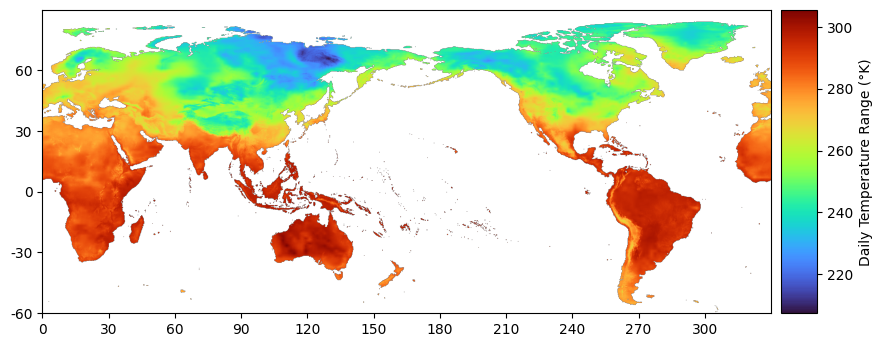

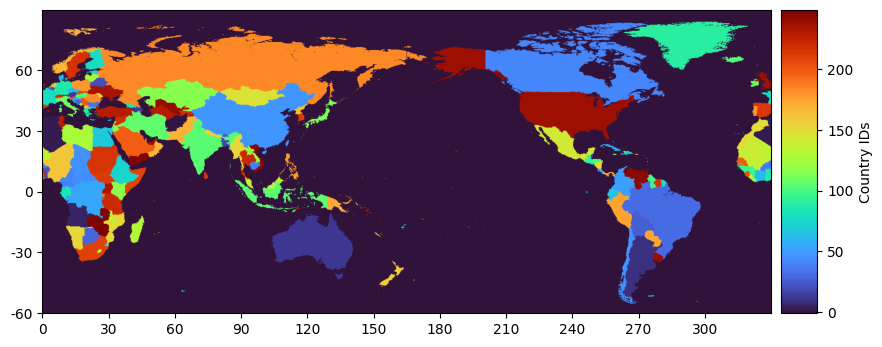

In [5]:
def show_map(data: np.ndarray, title: str):
    y_max, x_max = data.shape
    xlabels = [str(x) for x in range(0, 360, 30)]
    ylabels = [str(y) for y in range(-60, 91, 30)]
    xticks = np.linspace(0, x_max, len(xlabels))
    yticks = np.linspace(0, y_max, len(ylabels))
    
    # Create the plot
    fig, axes = plt.subplots(1, 1, figsize=(10, 8))
    axes.set_xticks(xticks)
    axes.set_xticklabels(xlabels)
    axes.set_yticks(yticks)
    axes.set_yticklabels(ylabels)
    
    # Plot the data
    im = axes.imshow(data[:, :], origin='lower', cmap='turbo')
    
    divider = make_axes_locatable(axes)
    cax = divider.append_axes("right", size="5%", pad=0.1)  # Adjust size and pad as needed
    
    # Add the colorbar
    cbar = plt.colorbar(im, cax=cax)
    cbar.set_label(title)
    
    # Show the plot
    plt.show()

show_map(ex_min_temps, 'Daily Temperature Range (°K)')
show_map(country_matrix, 'Country IDs')

### Step 6
Function `country_stats` is defined, allowing a matrix of world data to be converted into a single-dimension array of means--one per country. Note that some countries are too small to receive a mean, hence why there's a `nan` in the example output.

In [6]:
def country_stats(temp_data, country_matrix):
    # Return mean value of all of a country's longitude-latitude pairs
    # Index of value is same as country id
    stats = np.zeros((250, 2))
    for i in range(600):
        for j in range(1440):
            cid = country_matrix[i][j]
            trange = temp_data[i][j]
            if not np.isnan(trange) and cid != -1:
                stats[cid][0] += 1
                stats[cid][1] += trange
    with np.errstate(divide='ignore', invalid='ignore'):
        output = stats[:,1] / stats[:,0]
        return output

ex_country_min_temp_stats = country_stats(ex_min_temps, country_matrix)
print(ex_country_min_temp_stats[:10])

[264.20616924 267.94885699 278.05942452 300.20275879 262.87194824
 288.73991117 298.30969238          nan 297.14624023 288.12812915]


### Step 7
Function `graph_cstats` is defined, allowing the single-dimension array format to be graphed as a world map. The example output confirms the previous functions are working as intended.

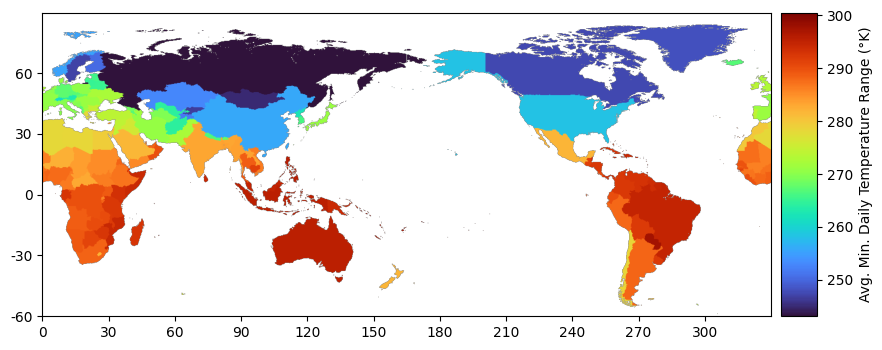

In [7]:
def graph_cstats(stats: np.ndarray, country_matrix: np.ndarray, title: str):
    # Display world with list of each country's value
    # Assumes country's value = stats[country's cid]
    toplot = np.full(country_matrix.shape, np.nan)
    for i in range(country_matrix.shape[0]):
        for j in range(country_matrix.shape[1]):
            cid = country_matrix[i][j]
            if cid != -1:
                toplot[i][j] = stats[cid]
    show_map(toplot, title)

graph_cstats(ex_country_min_temp_stats, country_matrix, 'Avg. Min. Daily Temperature Range (°K)')

### Step 8
Function `year_cstats` is defined and affords computing countries' daily temperatures across an entire year for a more consistent value. The example output is displayed to check validity.

Time to compute yearly temperature stats: 8.868471 seconds


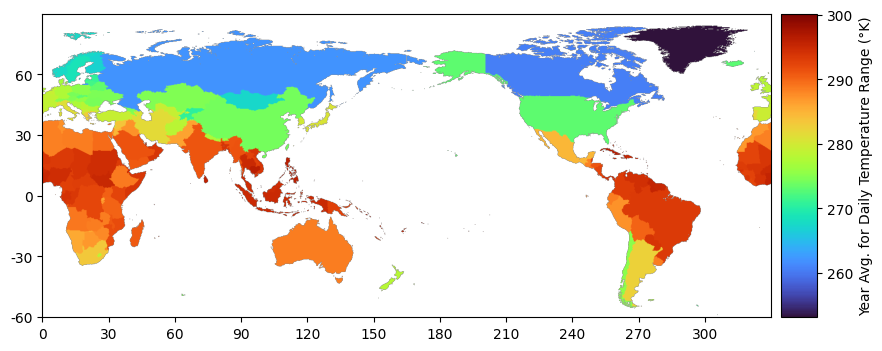

In [8]:
def year_cstats(datatype: str, year: int, n = 20):
    # Datatype is "min", "max", or "diff"
    # Generate timestamps to simulate within year
    def year_times(year: int, n = 20):
        timestamps = []
        dt = datetime(year=year, month=1, day=1)
        day_step = 365 // n
        for i in range(n):
            timestamps.append(dt.strftime('%Y-%m-%d'))
            dt += timedelta(days=day_step)
        return timestamps
        
    timestamps = year_times(year, n)
    aggs = np.zeros((250, 2))

    # Aggregate data
    for i in range(len(timestamps)):
        ts = timestamps[i]
        print(f"Processing {ts} ({i/n*100:.1f}%)", end='\r')
        tdata = None
        if datatype == "max":
            tdata = dbr.read(ts, domax=True)
        elif datatype == "min":
            tdata = dbr.read(ts, domax=False)
        elif datatype == "diff":
            tdata = dbr.read(ts, domax=True) - dbr.read(ts, domax=False)
        else:
            raise ValueError('Invalid datatype for year_cstats.')
        cstats = country_stats(tdata, country_matrix)
        aggs[:,0] += 1
        aggs[:,1] += cstats

    # Return list of means, one per country
    with np.errstate(divide='ignore', invalid='ignore'):
        return aggs[:,1]/aggs[:,0]

start = time.perf_counter()
y1_cstats = year_cstats("min", 1950, 5)
end = time.perf_counter()
elapsed = end - start
print(f"Time to compute yearly temperature stats: {elapsed:.6f} seconds")
graph_cstats(y1_cstats, country_matrix, 'Year Avg. for Daily Temperature Range (°K)')

### Step 9
The maximum, minimum, and difference between these values is measured for each country from the year 1980 to 2010.

In [9]:
def years_cstats(datatype: str, years: tuple[int, int], n = 20):
    # Index by year, country
    output = np.zeros((years[1]-years[0]+1, 250))
    year_list = range(years[0], years[1]+1)
    for i in range(len(year_list)):
        output[i] = year_cstats(datatype, year_list[i], n)
    return output

# Get min, max, and diff temperature statistics for each country from 1980 to 2010 (inclusive)
YEAR_TUPLE = (1980, 2010)
DATATYPES = ["min", "max", "diff"]
final_stats = []
for datatype in DATATYPES:
    filepath = f"cache/year_{datatype}_stats.bin"
    if not os.path.isfile(filepath):
        print(f"Processing \"{datatype}\" datatype...") 
        dt_stats = years_cstats(datatype, YEAR_TUPLE, 20)
        dt_stats.tofile(filepath)
        final_stats.append(dt_stats)
        print(f"Saved final country statistics to \"{filepath}\"")
    else:
        print(f"Loaded final country statistics from \"{filepath}\"")
        raw_dt_stats = np.fromfile(filepath)
        final_stats.append(
            raw_dt_stats.reshape((YEAR_TUPLE[1]-YEAR_TUPLE[0]+1, 250))
        )

Loaded final country statistics from "cache/year_min_stats.bin"
Loaded final country statistics from "cache/year_max_stats.bin"
Loaded final country statistics from "cache/year_diff_stats.bin"


### Step 10
Two helper functions, `gdp_arr` and `temp_stats_arr` are defined to retrieve graph-relevant GDP and temperature data, respectively. A scatter plot is generated for Mexico from the years 1980 to 2010 to comfirm the previous functions were working and check for any correlations.

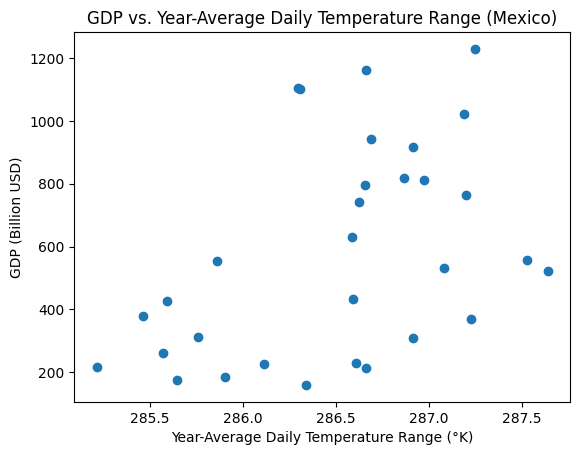

In [10]:
def gdp_arr(country: str):
    try:
        return gdps_df.loc[gdps_df["COUNTRY"] == country].iloc[0].to_numpy()[3:-14]
    except:
        return None

def temp_stats_arr(datatype: str, country: str):
    cf = CountryFinder()
    cid = cf.name_to_cid(country)
    if datatype == "min":
        return final_stats[0][:,cid]
    elif datatype == "max":
        return final_stats[1][:,cid]
    elif datatype == "diff":
        return final_stats[2][:,cid]
    else:
        raise ValueError('Invalid datatype for temp_stats_arr.')

plt.scatter(temp_stats_arr("min", "Mexico"), gdp_arr("Mexico"))
plt.title("GDP vs. Year-Average Daily Temperature Range (Mexico)")
plt.xlabel("Year-Average Daily Temperature Range (°K)")
plt.ylabel("GDP (Billion USD)")
plt.show()
plt.close()

### Step 11
Each country's GDP and temperature statistics are paired and the country is plotted three times each year from 1980 to 2010. A total of 93 scatter plots are made. These plots are stored in the file system to be converted into GIFs.

In [11]:
TITLES = [
    "Year-Average Min. Daily Temperature",
    "Year-Average Max. Daily Temperature",
    "Year-Average Daily Temperature Range"
]

XLIMS = [
    (260, 320),
    (260, 320),
    (0, 20)
]

# Verify plots directory exists
if not os.path.exists("plots"):
    os.mkdir("plots")

for i in range(len(DATATYPES)):
    datatype = DATATYPES[i]
    title = TITLES[i]
    xlim = XLIMS[i]
    print(f"Processing \"{datatype}\"...")

    # Generate directory for storing plots
    if not os.path.exists(f"plots/{datatype}"):
        os.mkdir(f"plots/{datatype}")
    
        # Populate dictionary for plotting data
        gif_data_dict = {}
        for country in gdp_countries:
            gif_data_dict[country] = (temp_stats_arr(datatype, country), gdp_arr(country))
            print(f"Processing {country + "...": <50}", end='\r')
        print("Finished generating dictionary!")
    
        # Fill directory with rendered plots
        for i in range(YEAR_TUPLE[1] - YEAR_TUPLE[0] + 1):
            year = YEAR_TUPLE[0] + i
            print(f"Processing {year}...", end='\r')
            for country in gdp_countries:
                arrs = gif_data_dict[country]
                plt.scatter(arrs[0][i], arrs[1][i])
                plt.yscale('log')
            
            plt.title(f"GDP vs. {title} ({year})")
            plt.xlabel(f"{title} (°K)")
            plt.ylabel("GDP (Billion USD)")
            plt.ylim((.05, 50000))
            plt.xlim(xlim)
            plt.savefig(f"plots/{datatype}/{year}")
            plt.close()
        
        print("Finished creating GDP scatter plots!")
    else:
        print("Already created GDP scatter plots.")

Processing "min"...
Already created GDP scatter plots.
Processing "max"...
Already created GDP scatter plots.
Processing "diff"...
Already created GDP scatter plots.


### Step 12
GIFs are generated from each directory of scatter plots. Each GIF is displayed below.

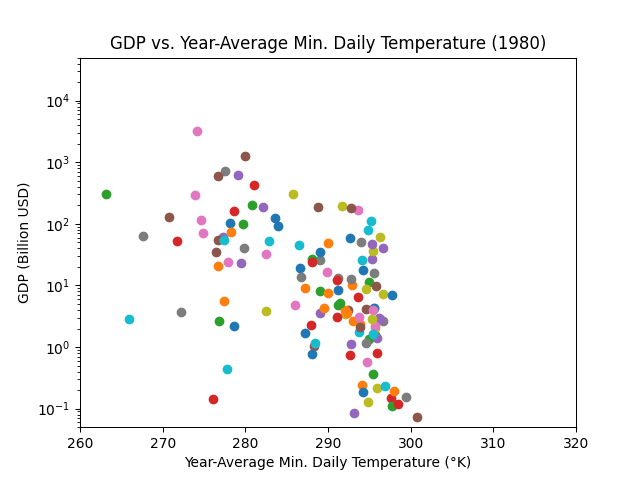

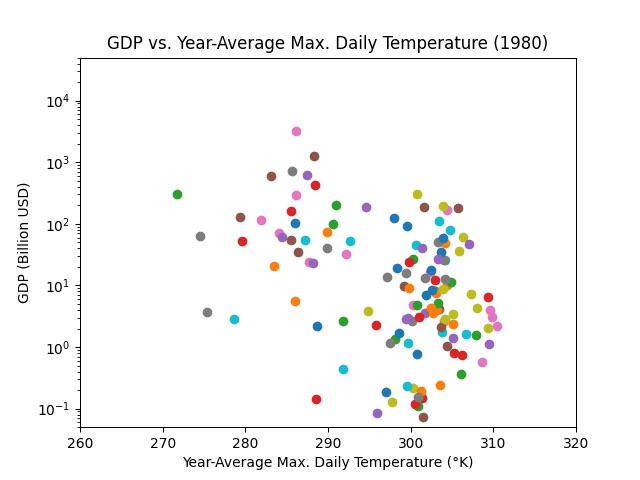

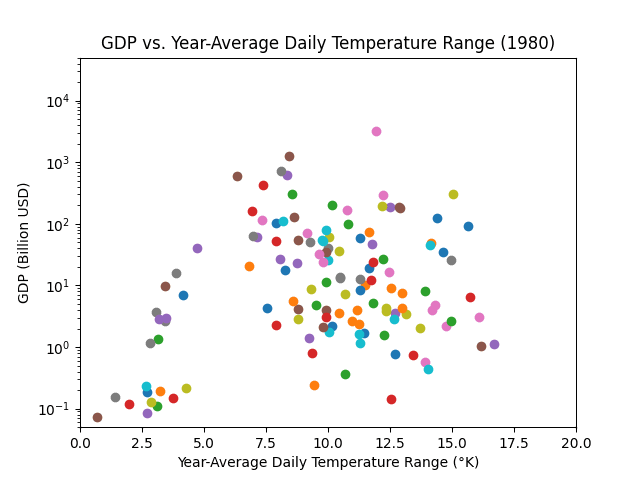

In [12]:
def view_gif(dirpath: str):
    # Constants
    FPS = 5

    # Scan directory for files to read
    if not os.path.exists(dirpath):
        raise ValueError(f"Directory not found: {rel_dir}")
    files = [x for x in os.listdir(dirpath) if x.endswith(".png")]

    # Sort files by their year
    files.sort(key=lambda name: int(name[:-4]))

    # Read images, forcing all to be same size
    imgs = [Image.open(f"{dirpath}/{file}").convert("RGBA") for file in files]
    base_w, base_h = imgs[0].size
    for i, im in enumerate(imgs):
        if im.size != (base_w, base_h):
            imgs[i] = im.resize((base_w, base_h), Image.LANCZOS)

    # Generate GIF
    buf = io.BytesIO()
    imgs[0].save(
        buf,
        format="GIF",
        save_all=True,
        append_images=imgs[1:],
        duration=1000/FPS,
        loop=False,
        disposal=2,
        optimize=False,
        transparency=0
    )
    buf.seek(0)
    display(IPyImage(data=buf.getvalue()))

for datatype in DATATYPES:
    view_gif(f"plots/{datatype}")